In [1]:
import time
from datetime import timedelta
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import json
import csv
from datetime import datetime
from patchify import patchify, unpatchify

/home/calebe/geo-projects-car/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_image = '/data/integracar/amostras_car_orotofoto/'
path_mask = '/data/integracar/amostras_car_mask/'

In [3]:
with open("debugging_images.txt", 'r') as f:
    image_names = [line.strip() for line in f.readlines()]

In [4]:
image_names

['ES-3202405-4F8952863DD3405E99B3A4FDD85E0A65.tif',
 'ES-3200607-B6337FA0E1C44488886169D0F80C4AF2.tif',
 'ES-3205036-3286F5B872A54287A95DCE6EFB165A68.tif',
 'ES-3205150-943F6913731C46A684B2775D170C3AD0.tif']

In [5]:
patches_per_row = 1024 // 512
patches_per_row

2

In [6]:
p_p_images = patches_per_row **2
p_p_images

4

In [7]:
len(image_names) * p_p_images

16

In [8]:
path_list = []
for image in range(0,4):
    path_list.append(os.path.join(path_image, image_names[image]))

In [9]:
path_list

['/data/integracar/amostras_car_orotofoto/ES-3202405-4F8952863DD3405E99B3A4FDD85E0A65.tif',
 '/data/integracar/amostras_car_orotofoto/ES-3200607-B6337FA0E1C44488886169D0F80C4AF2.tif',
 '/data/integracar/amostras_car_orotofoto/ES-3205036-3286F5B872A54287A95DCE6EFB165A68.tif',
 '/data/integracar/amostras_car_orotofoto/ES-3205150-943F6913731C46A684B2775D170C3AD0.tif']

In [10]:
mask_list = []
for image in range(0,4):
    mask_list.append(os.path.join(path_mask, image_names[image]))

In [11]:
mask_list

['/data/integracar/amostras_car_mask/ES-3202405-4F8952863DD3405E99B3A4FDD85E0A65.tif',
 '/data/integracar/amostras_car_mask/ES-3200607-B6337FA0E1C44488886169D0F80C4AF2.tif',
 '/data/integracar/amostras_car_mask/ES-3205036-3286F5B872A54287A95DCE6EFB165A68.tif',
 '/data/integracar/amostras_car_mask/ES-3205150-943F6913731C46A684B2775D170C3AD0.tif']

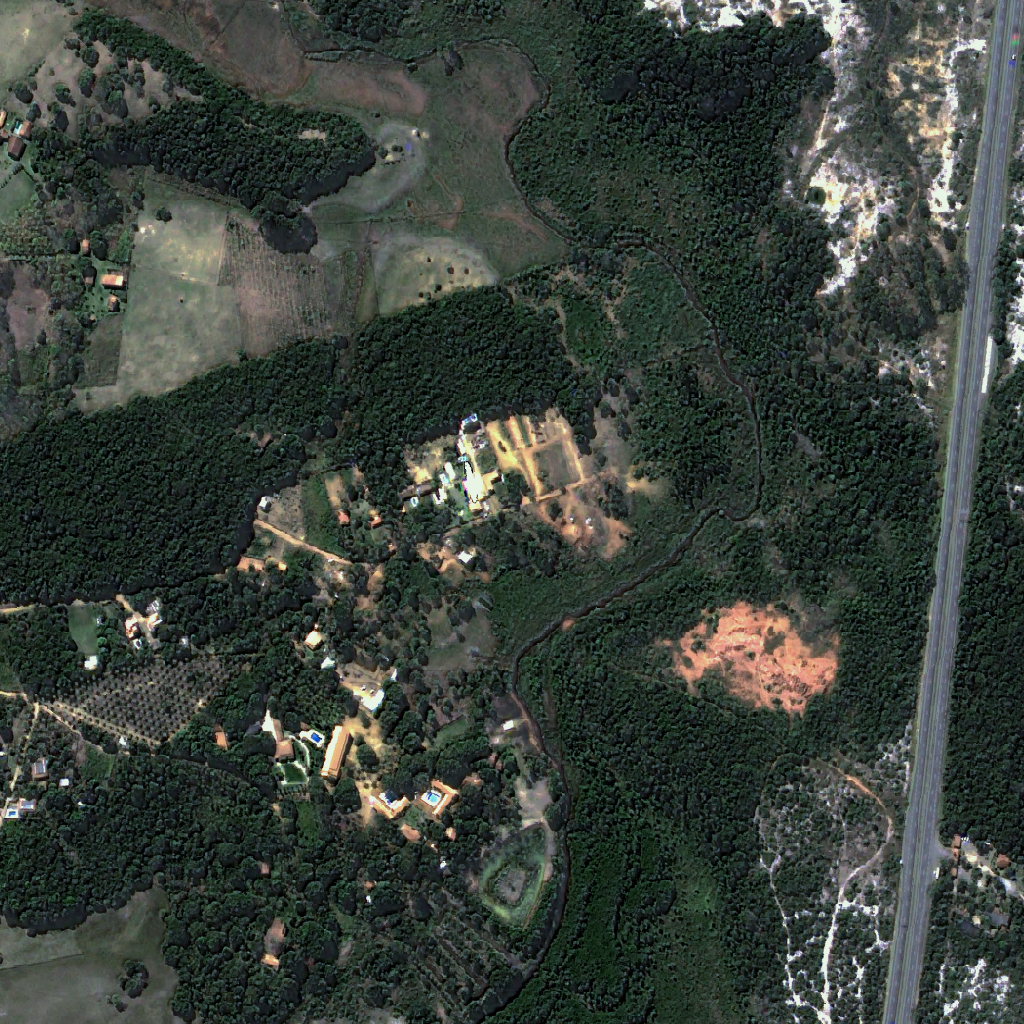

In [12]:
image_sat = Image.open(path_list[0]).convert('RGB')
image_sat

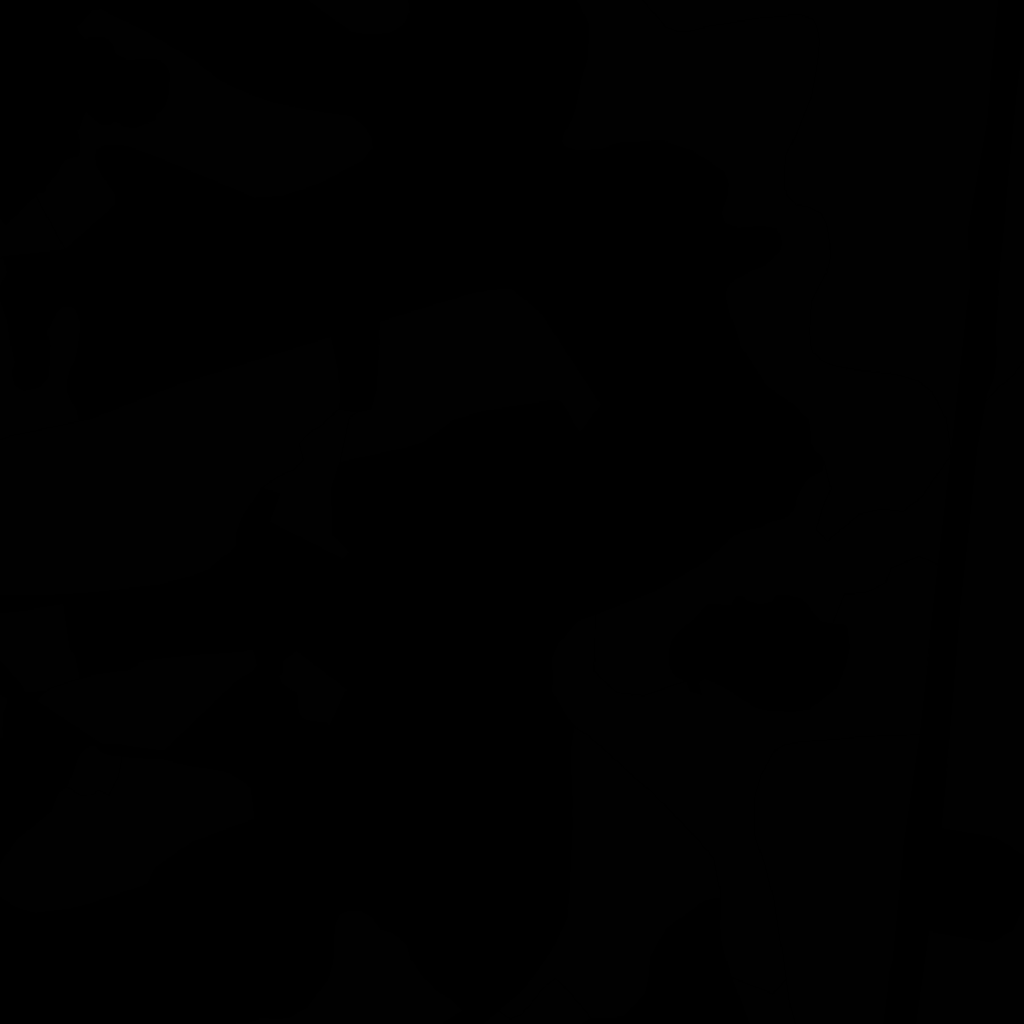

In [13]:
image_mask = Image.open(mask_list[0]).convert('L')
image_mask

In [14]:
image_np = np.array(image_sat)
image_np

array([[[ 94, 100,  87],
        [ 95, 103,  90],
        [ 92, 103,  89],
        ...,
        [117, 116, 131],
        [114, 115, 123],
        [114, 115, 123]],

       [[ 98, 104,  91],
        [ 98, 104,  92],
        [ 95, 103,  91],
        ...,
        [110, 114, 128],
        [111, 110, 121],
        [111, 110, 121]],

       [[110, 120, 106],
        [102, 114,  99],
        [ 98, 112,  97],
        ...,
        [116, 122, 137],
        [ 97,  98, 108],
        [ 97,  98, 108]],

       ...,

       [[ 89,  96,  85],
        [ 91,  97,  86],
        [ 91, 100,  89],
        ...,
        [ 73,  82,  73],
        [ 72,  83,  76],
        [ 48,  58,  51]],

       [[ 92,  96,  84],
        [ 91,  95,  84],
        [ 89,  93,  82],
        ...,
        [ 64,  74,  64],
        [ 66,  77,  72],
        [ 52,  60,  54]],

       [[ 93,  95,  85],
        [ 92,  92,  82],
        [ 88,  91,  81],
        ...,
        [ 44,  52,  43],
        [ 52,  66,  56],
        [ 58,  72,  69]]

In [15]:
mask_np = np.array(image_mask)
mask_np

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], dtype=uint8)

In [16]:
image_patches = patchify(image_np, (512, 512, 3), step=256)
image_patches

array([[[[[[ 94, 100,  87],
           [ 95, 103,  90],
           [ 92, 103,  89],
           ...,
           [ 34,  50,  41],
           [ 31,  47,  35],
           [ 43,  60,  49]],

          [[ 98, 104,  91],
           [ 98, 104,  92],
           [ 95, 103,  91],
           ...,
           [ 32,  48,  36],
           [ 38,  53,  44],
           [ 45,  65,  51]],

          [[110, 120, 106],
           [102, 114,  99],
           [ 98, 112,  97],
           ...,
           [ 47,  68,  54],
           [ 44,  63,  49],
           [ 43,  62,  47]],

          ...,

          [[ 49,  68,  62],
           [ 45,  63,  55],
           [ 22,  35,  22],
           ...,
           [124, 125, 118],
           [123, 125, 117],
           [121, 129, 118]],

          [[  2,   8,   2],
           [  3,   8,   1],
           [ 14,  24,  11],
           ...,
           [100, 100,  78],
           [119, 119,  99],
           [123, 128, 111]],

          [[ 14,  26,  13],
           [  7,  14,   5]

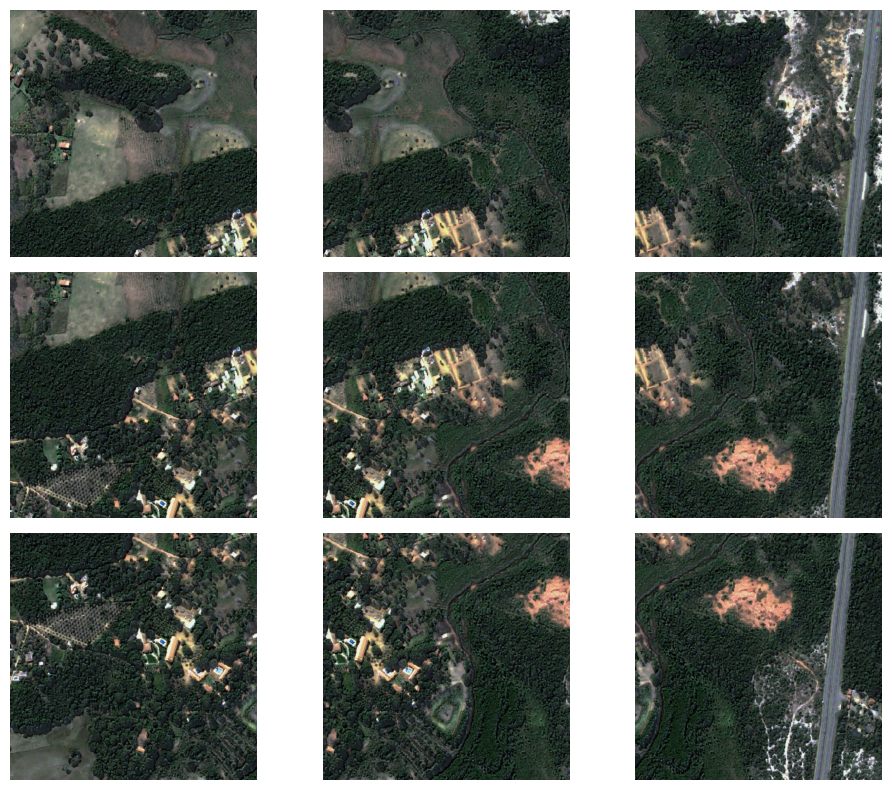

In [17]:
# Supondo que 'patches' já foi gerado como no código acima
n_rows = image_patches.shape[0]
n_cols = image_patches.shape[1]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 8))

for i in range(n_rows):
    for j in range(n_cols):
        # Extrai o patch [i, j]
        # O index 0 é usado para acessar o conteúdo dentro da dimensão extra criada pelo patchify
        patch_image = image_patches[i, j, 0, :, :, :]
        
        # Exibe no subplot correspondente
        if n_rows == 1 or n_cols == 1: # Tratamento para caso só tenha 1 linha ou coluna
             ax = axes[max(i, j)]
        else:
             ax = axes[i, j]
             
        ax.imshow(patch_image)
        ax.axis('off') # Remove eixos para limpar o visual

plt.tight_layout()
plt.show()


In [18]:
!pip install pytest


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [19]:
!python -m pytest

/home/calebe/geo-projects-car/venv/bin/python: No module named pytest
